# Week 1 · Day 2 — Data Is the Fuel — Preparing Data for AI

**Course:** IPAM USL 5-Week Short Course: Introduction to Artificial Intelligence *(Introductory tier)*

**Facilitator:** Solomon Wilson MBCS | PhD Student, Computer Science | Deputy HOD Transport Planning & Operations | HOD, IT & Audit Supervisor, SLPTA

**Mode:** Google Colab (zero-install)

**Mental model layer:** L2 — Data as Fuel

**Running scenario:** Route **R12** (Wilberforce → CBD) — operator OP-104, 25-minute delay


**Module:** 1 · **Week:** 1 · **Tier:** Intro  
**New concept:** Data quality determines model quality — dirty data produces wrong predictions  
**Deliverable wired in:** None

## Learning objectives
By the end of today you will be able to:
- Inspect a real-looking SLPTA dataset and spot **missing values**, **duplicates**, and **outliers**.
- Clean those problems and **encode** a categorical column into numbers a model can use.
- Split data into a **training set** and a **test set**, and explain why we keep them separate.

## Why this matters for SLPTA

Tomorrow we will train a model to predict which trips run badly late — like **R12**'s 25-minute delay. But a model can only learn from the route log we feed it, and that log is messy: some weather readings are blank, a few delays were typed in wrong, some rows are duplicated.

> *Garbage in, garbage out.* If the data is dirty, the model's advice to dispatch will be wrong — confidently. Cleaning data is not boring admin; it is where model quality is won or lost.

## Environment setup

In [1]:
# Today's lab uses pandas (preinstalled in Colab). We also install google-genai
# so that the SAME bootstrap import line works in every notebook this course —
# even though we will not call a language model until Day 9.
!pip install -q google-genai
print("Environment ready.")

Environment ready.


In [2]:
# --- Standard SLPTA bootstrap (identical in every notebook) ----------------
import sys
from pathlib import Path

# Find the folder that holds shared/slpta_bootstrap.py, wherever the repo sits.
for candidate in [Path.cwd(), *Path.cwd().parents,
                  Path("/content/IPAM_USL_Intro_AI_5Week")]:
    if (candidate / "shared" / "slpta_bootstrap.py").exists():
        sys.path.insert(0, str(candidate / "shared"))
        break

from slpta_bootstrap import (MODEL, ensure_course_data, get_client,
                             load_route12_context, load_route_logs,
                             load_complaints, load_routes, load_operators)

ensure_course_data()          # generates course_data/ on first run (no-op after)
print("Model configured:", MODEL)
print(load_route12_context())

Model configured: gemini-2.0-flash
Route R12 (Wilberforce → CBD). The 07:45 service, operated by OP-104 on vehicle SLPTA-1142, departed 25 minutes late. Recorded cause: Heavy traffic on Wilkinson Road. About 40 passengers were affected and the dispatch desk received multiple complaints. (Synthetic SLPTA scenario — no real data.)


## Concept — first principles

A dataset is a table: each **row** is one observation (here, one bus trip) and each **column** is a **feature** (something we know about that trip). Before any AI, we must make the table trustworthy:

1. **Missing values** — blanks the model cannot read. We either drop them or **impute** (fill with a sensible substitute).
2. **Duplicates / outliers** — repeated or impossible rows that distort what the model learns.
3. **Encoding** — models do maths, so text categories like `Rain` must become numbers.
4. **Train/test split** — we hide some rows from the model so we can fairly test it later, like setting exam questions a student has not seen.

*Jargon, defined once:* to **impute** = to fill a missing value with a reasonable estimate (e.g. the most common weather).

<p align="center"></p>

<!-- cell-diagram:c09 -->
<p align="center"></p>

### Check your understanding (before running)
**Predict** two things before you run the next cell:
1. Which column do you think has the **most** missing values — `weather` or `passenger_count`?
2. Will average delay be **higher** on rainy trips or sunny trips?

In [3]:
import pandas as pd

logs = load_route_logs()
print("Shape (rows, columns):", logs.shape)
logs.head()

Shape (rows, columns): (1864, 13)


,trip_id,date,day_of_week,route_id,operator_id,scheduled_hour,peak_period,weather,cause_category,distance_km,passenger_count,fare_leones,delay_minutes
0,T00001,2025-02-03,Mon,R12,OP-118,20,False,Sunny,Normal,11.2,8.0,5000,0.0
1,T00002,2025-02-03,Mon,R12,OP-109,10,False,Sunny,Mechanical,11.2,5.0,5000,13.2
2,T00003,2025-02-03,Mon,R12,OP-109,19,False,Rain,Staffing,11.2,24.0,5000,23.0
3,T00004,2025-02-03,Mon,R12,OP-114,20,False,Sunny,Normal,11.2,27.0,5000,0.9
4,T00005,2025-02-03,Mon,R12,OP-114,12,False,Sunny,Normal,11.2,6.0,5000,3.8


<!-- cell-diagram:c11 -->
<p align="center"></p>

### Check your understanding (before running)
We already saw the shape is (1864, 13). We are about to count missing values per column.

**Predict:** Which column do you think has the most missing values — `weather` or `passenger_count`? And what do you expect the maximum `delay_minutes` value to be — under 60, under 120, or over 120?

*Write your prediction in a new text cell below, then run.*

In [4]:
# How many values are missing in each column?
missing = logs.isna().sum()
print("Missing values per column:")
print(missing[missing > 0].to_string())

Missing values per column:
weather            119
passenger_count    100


<!-- cell-diagram:c12 -->
<p align="center"></p>

### Check your understanding (before running)
Gemini will summarise the pasted R12 incident report in a few sentences.

**Predict:** Will the summary mention the **25-minute delay** and **OP-104** without making up facts?

In [5]:
# A quick numeric summary. Look at delay_minutes: does the maximum look sane?
logs[["delay_minutes", "passenger_count", "distance_km"]].describe().round(1)

,delay_minutes,passenger_count,distance_km
count,1864.0,1764.0,1864.0
mean,12.1,20.2,13.1
std,25.9,10.6,6.9
min,0.0,0.0,7.1
25%,3.2,12.0,9.4
50%,9.9,19.0,11.2
75%,17.2,26.0,12.8
max,630.7,71.0,28.0


The maximum `delay_minutes` is impossibly large — a data-entry slip (someone added an extra digit). And `passenger_count`/`weather` have blanks. Let's visualise before we fix.

<!-- cell-diagram:c15 -->
<p align="center"></p>

### Check your understanding (before running)
We are about to plot the distribution of delay minutes and average delay by weather condition.

**Predict:** Which weather condition do you expect to have the highest average delay — `Sunny`, `Rain`, or `Heavy Rain`? Is that what the data shows?

*Write your prediction in a new text cell below, then run.*

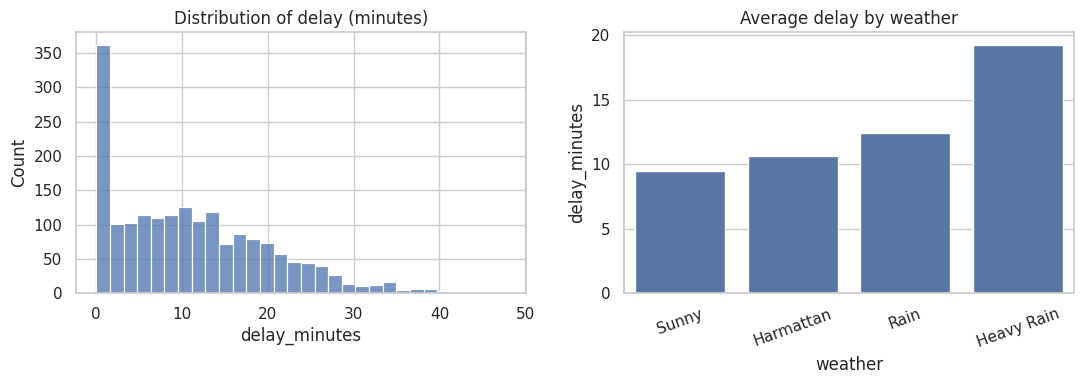

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Drop the obvious typos (>180 min) just for this chart so the scale is readable.
plot_df = logs[logs["delay_minutes"] < 180]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(plot_df["delay_minutes"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of delay (minutes)")

order = ["Sunny", "Harmattan", "Rain", "Heavy Rain"]
sns.barplot(data=plot_df, x="weather", y="delay_minutes", order=order,
            errorbar=None, ax=axes[1])
axes[1].set_title("Average delay by weather")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Demo — clean the data step by step

<!-- cell-diagram:c18 -->
<p align="center"></p>

### Check your understanding (before running)
We are about to clean the route log in four steps: remove duplicates, drop extreme delays, impute missing weather, and impute missing passenger counts.

**Predict:** After cleaning, do you expect more or fewer than 1,850 rows to remain? Which step do you think removes the most rows?

*Write your prediction in a new text cell below, then run.*

In [ ]:
clean = logs.copy()

# 1. Remove exact duplicate rows.
before = len(clean)
clean = clean.drop_duplicates()
print(f"Removed {before - len(clean)} duplicate rows.")

# 2. Remove impossible delays (data-entry errors): keep trips under 3 hours.
before = len(clean)
clean = clean[clean["delay_minutes"] < 180]
print(f"Removed {before - len(clean)} outlier delay rows.")

# 3. Impute missing weather with the most common value (the mode).
mode_weather = clean["weather"].mode()[0]
clean["weather"] = clean["weather"].fillna(mode_weather)
print(f"Filled missing weather with: {mode_weather}")

# 4. Impute missing passenger_count with the median (robust to extremes).
median_pax = clean["passenger_count"].median()
clean["passenger_count"] = clean["passenger_count"].fillna(median_pax)
print(f"Filled missing passenger_count with median: {median_pax}")

print("Remaining missing values:", int(clean.isna().sum().sum()))

Removed 8 duplicate rows.
Removed 3 outlier delay rows.
Filled missing weather with: Sunny
Filled missing passenger_count with median: 19.0
Remaining missing values: 0


<!-- cell-diagram:c20 -->
<p align="center"></p>

### Check your understanding (before running)
We are about to encode the `weather` column — converting text like `'Rain'` into numbers a model can use.

**Predict:** How many new columns do you expect `pd.get_dummies` to create for a column with four distinct weather values (`Sunny`, `Harmattan`, `Rain`, `Heavy Rain`)?

*Write your prediction in a new text cell below, then run.*

In [ ]:
# Encoding: turn the text column "weather" into numeric columns (one per value).
# This is called one-hot encoding. Watch the new 0/1 columns appear.
encoded = pd.get_dummies(clean, columns=["weather"], prefix="wx")
encoded.filter(like="wx_").head()

,wx_Harmattan,wx_Heavy Rain,wx_Rain,wx_Sunny
0,False,False,False,True
1,False,False,False,True
2,False,False,True,False
3,False,False,False,True
4,False,False,False,True


<!-- cell-diagram:c22 -->
<p align="center"></p>

### Check your understanding (before running)
We are about to split the cleaned route log into a training set and a test set.

**Predict:** If we use 25 % for testing, and there are about 1,850 rows after cleaning, roughly how many rows will be in the training set? Write your estimate.

*Write your prediction in a new text cell below, then run.*

In [ ]:
from sklearn.model_selection import train_test_split

# Features (X) = what we know; target (y) = what we want to predict tomorrow.
y = (clean["delay_minutes"] > 15).astype(int)   # 1 = badly delayed, 0 = not
X = clean.drop(columns=["delay_minutes", "trip_id", "date"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)
print(f"Training rows: {len(X_train)}   Test rows: {len(X_test)}")
print(f"Share of 'badly delayed' trips overall: {y.mean():.0%}")

Training rows: 1389   Test rows: 464
Share of 'badly delayed' trips overall: 30%


### Exercise — change one thing and observe

Change the **test size** below from `0.25` to `0.40` and re-run. Watch how the training and test row counts move. Bigger test set = a fairer exam, but fewer rows to learn from.

<!-- cell-diagram:c24 -->
<p align="center"></p>

### Check your understanding (before running)
You will change `test_size` to **0.40** and print train/test row counts.

**Predict:** Will the test set get bigger or smaller than the default 0.20 split?

In [ ]:
# TODO: change test_size to 0.40, then re-run and read the printed counts.
test_size = 0.25   # <-- change me

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size,
                                      random_state=0, stratify=y)
print(f"test_size = {test_size}  ->  train rows: {len(Xtr)}, test rows: {len(Xte)}")

test_size = 0.25  ->  train rows: 1389, test rows: 464


## Check your understanding
1. Why do we **hide** the test set from the model instead of training on all the data?
2. We filled missing `passenger_count` with the *median* rather than the *mean*. Given the outliers we saw, why is the median safer here?
3. The route log has no passenger names or phone numbers. Why does that matter for a public authority like SLPTA?

### Your answers
*Double-click to edit this cell and type your answers here.*

1.
2.
3.

## If you remember one thing today…

> **A model is only ever as good as the data you feed it — clean the data first.**

## Submission checklist
- [ ] Run every code cell successfully (top to bottom)
- [ ] Complete the exercise (fill every blank / make the requested change)
- [ ] Answer the **Check your understanding** questions in the markdown cell provided
- [ ] Save a clean copy of the notebook (*File → Save a copy in Drive*)